# Прогнозирование временного ряда акций «Лукойл»

В работе решается задача прогнозирования цены закрытия акций компании «Лукойл» на основе исторических биржевых данных. Рассматриваются две архитектуры: полносвязная нейронная сеть и сеть со слоями Conv1D. Для каждой архитектуры обучаются две модели — на прогнозирование одного шага вперёд и на прогнозирование сразу десяти шагов прямым способом (когда сеть выдаёт вектор из 10 значений за один проход).

Этапы работы:

1. Загрузка библиотек и подготовка данных.
2. Нормализация и формирование обучающей и тестовой выборок.
3. Обучение полносвязной сети для прогноза на один шаг вперёд.
4. Обучение полносвязной сети для прогноза на 10 шагов вперёд прямым способом.
5. Построение графиков сравнения предсказания и оригинального сигнала по каждому из 10 шагов.
6. Повторение пунктов 3–5 для архитектуры со свёрточным слоем Conv1D.

Все нейросетевые модели реализованы на PyTorch.

## Загрузка библиотек

In [ ]:
# Работа с массивами
import numpy as np

# Работа с таблицами
import pandas as pd

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Нормировщики
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Загрузка датасетов из облака google
import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

# Отрисовка графики в ячейке colab
%matplotlib inline

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

# Выбор устройства для обучения
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Устройство:', device)

Устройство: cuda


In [ ]:
# Назначение размера и стиля графиков по умолчанию
from pylab import rcParams
plt.style.use('ggplot')
rcParams['figure.figsize'] = (14, 7)

# Фиксация случайных значений для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Загрузка данных

Используется база котировок акций «Лукойл» за 2016–2019 годы. Данные загружаются из облачного хранилища двумя файлами и затем объединяются в один массив.

In [ ]:
# Загрузка датасетов из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/16_17.csv', None, quiet=True)
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l11/18_19.csv', None, quiet=True)

'18_19.csv'

In [ ]:
# Чтение данных в таблицы pandas, столбцы DATE и TIME удаляются за ненадобностью
data16_17 = pd.read_csv('16_17.csv', sep=';').drop(columns=['DATE', 'TIME'])
data18_19 = pd.read_csv('18_19.csv', sep=';').drop(columns=['DATE', 'TIME'])

# Просмотр размерностей
print(data16_17.shape)
print(data18_19.shape)

(263925, 5)
(217947, 5)


In [ ]:
# Объединение двух датасетов в один общий массив
data = pd.concat([data16_17, data18_19]).to_numpy()
print('Форма общего набора данных:', data.shape)

Форма общего набора данных: (481872, 5)


По условию задачи прогнозируется только цена закрытия (Close), поэтому из общего массива выделяется один соответствующий столбец.

In [ ]:
# Индексы каналов исходного датасета: Open, Max, Min, Close, Volume
CHANNEL_NAMES = ['Open', 'Max', 'Min', 'Close', 'Volume']
CLOSE_INDEX = CHANNEL_NAMES.index('Close')

# Отбор только канала Close в виде столбца
close_series = data[:, CLOSE_INDEX].reshape(-1, 1)
print('Форма ряда цены закрытия:', close_series.shape)

Форма ряда цены закрытия: (481872, 1)


### Иллюстрация исходного ряда

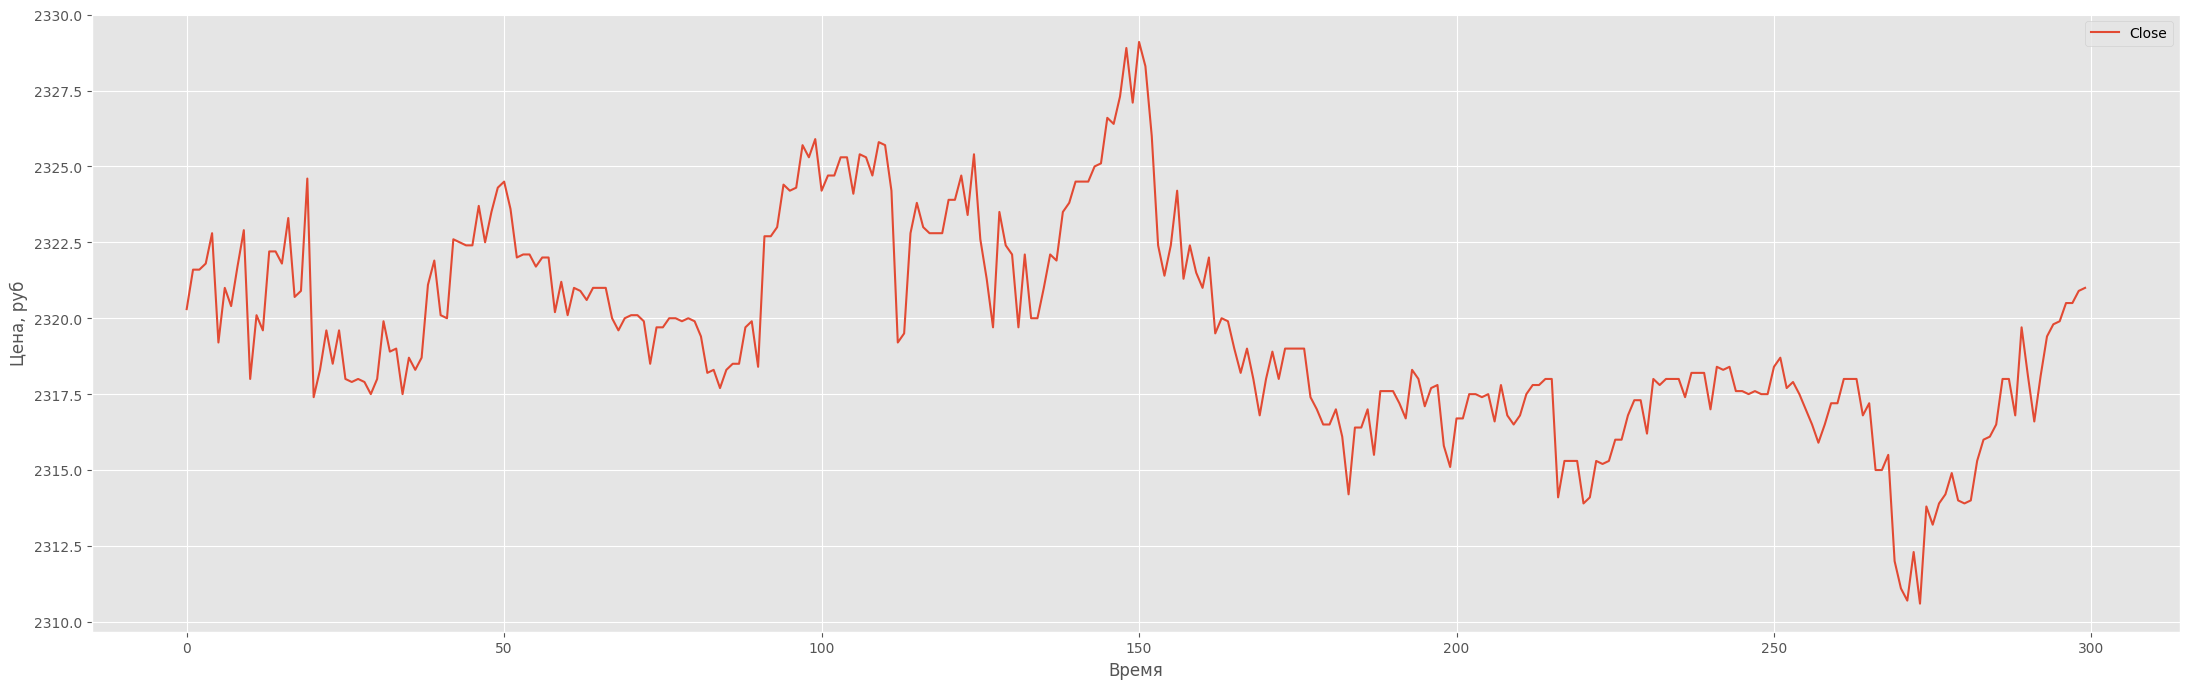

In [ ]:
# Отображение фрагмента ряда цены закрытия
start = 100
length = 300

plt.figure(figsize=(22, 7))
plt.plot(close_series[start:start + length], label='Close')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.tight_layout()
plt.show()

## Подготовка выборок

Данные разделяются на обучающую и тестовую части в хронологическом порядке. Для устранения пересечения между выборками между ними оставляется зазор длиной в две длины анализируемой последовательности. После разделения значения масштабируются с помощью MinMaxScaler, обученного только на тренировочных данных.

In [ ]:
# Гиперпараметры подготовки данных
SEQ_LEN = 60                              # Длина анализируемой подпоследовательности
BATCH_SIZE = 64                           # Размер батча
TEST_LEN = 30000                          # Размер тестовой части
TRAIN_LEN = close_series.shape[0] - TEST_LEN  # Размер обучающей части

In [ ]:
# Разделение по времени с зазором между обучением и тестом
data_train = close_series[:TRAIN_LEN]
data_test = close_series[TRAIN_LEN + 2 * SEQ_LEN:]

# Нормировщик настраивается по обучающим данным
scaler = MinMaxScaler()
scaler.fit(data_train)

# Преобразование обеих частей
data_train_sc = scaler.transform(data_train).astype(np.float32)
data_test_sc  = scaler.transform(data_test).astype(np.float32)

print('Train:', data_train_sc.shape)
print('Test :', data_test_sc.shape)

Train: (451872, 1)
Test : (29880, 1)


### Формирование окон

Для обучения ряд нарезается на окна длиной `SEQ_LEN`: на вход сети подаётся окно, на выходе ожидается следующее значение (для одношагового прогноза) или следующие 10 значений (для многошагового). На больших рядах хранить все окна в памяти одновременно расточительно — материализованный массив занимал бы порядка нескольких гигабайт оперативной памяти. Поэтому используется ленивый набор данных: окна формируются на лету в `__getitem__`, а в памяти хранится только сам исходный ряд.

In [ ]:
# Ленивый набор данных, который нарезает окна непосредственно при обращении
class SeriesWindowDataset(torch.utils.data.Dataset):
    def __init__(self, series, seq_len, predict_lag):
        # Хранится один общий тензор ряда, окна вырезаются по индексу
        self.series = torch.from_numpy(series)
        self.seq_len = seq_len
        self.predict_lag = predict_lag
        self.length = series.shape[0] - seq_len - predict_lag + 1
        if self.length <= 0:
            raise ValueError('Слишком короткий ряд для заданных параметров')

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        x = self.series[idx:idx + self.seq_len]
        if self.predict_lag == 1:
            y = self.series[idx + self.seq_len]
        else:
            # Один канал, поэтому берётся столбец 0
            y = self.series[idx + self.seq_len:idx + self.seq_len + self.predict_lag, 0]
        return x, y

In [ ]:
# Горизонт многошагового прогноза
PREDICT_LAG = 10

# Наборы данных для одношагового и многошагового прогноза
train_ds_1  = SeriesWindowDataset(data_train_sc, SEQ_LEN, predict_lag=1)
test_ds_1   = SeriesWindowDataset(data_test_sc,  SEQ_LEN, predict_lag=1)
train_ds_10 = SeriesWindowDataset(data_train_sc, SEQ_LEN, predict_lag=PREDICT_LAG)
test_ds_10  = SeriesWindowDataset(data_test_sc,  SEQ_LEN, predict_lag=PREDICT_LAG)

print('1 шаг   train:', len(train_ds_1),  'test:', len(test_ds_1))
print('10 шагов train:', len(train_ds_10), 'test:', len(test_ds_10))

1 шаг   train: 451812 test: 29820
10 шагов train: 451803 test: 29811


In [ ]:
# DataLoader'ы поверх ленивых наборов
def make_loaders(train_ds, test_ds, batch_size=BATCH_SIZE):
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

train_loader_1,  test_loader_1  = make_loaders(train_ds_1,  test_ds_1)
train_loader_10, test_loader_10 = make_loaders(train_ds_10, test_ds_10)

## Сервисные функции обучения и оценки

Универсальные функции, которые используются для всех моделей: одна эпоха обучения, оценка ошибки на тестовой выборке, общий цикл обучения с накоплением истории и получение прогноза по всему массиву входов.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)
    return total_loss / total_n


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_n = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)
    return total_loss / total_n


def fit(model, train_loader, test_loader, epochs, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    history = {'loss': [], 'val_loss': []}
    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate(model, test_loader, criterion)
        history['loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'Эпоха {epoch:3d}/{epochs}   loss = {train_loss:.6f}   val_loss = {val_loss:.6f}')
    return history


@torch.no_grad()
def predict_all(model, dataset, batch_size=256):
    # Прогноз по всему набору данных батчами, возвращаются numpy-массивы (y_pred, y_true)
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    preds, trues = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        preds.append(model(xb).cpu().numpy())
        trues.append(yb.numpy())
    return np.concatenate(preds, axis=0), np.concatenate(trues, axis=0)


def plot_history(history, title):
    plt.figure(figsize=(14, 7))
    plt.plot(history['loss'], label='Ошибка на обучающем наборе')
    plt.plot(history['val_loss'], label='Ошибка на проверочном наборе')
    plt.title(title)
    plt.xlabel('Эпоха')
    plt.ylabel('MSE')
    plt.legend()
    plt.show()

## Часть 1. Полносвязная сеть, прогноз на 1 шаг

Простейшая архитектура: разворачивание окна в одномерный вектор, скрытый полносвязный слой и линейный выход с одним нейроном.

In [ ]:
# Простая полносвязная сеть с одним выходом
class DenseModel1(nn.Module):
    def __init__(self, seq_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len, 150),
            nn.ReLU(),
            nn.Linear(150, 1),
        )

    def forward(self, x):
        return self.net(x)


model_dense_1 = DenseModel1(SEQ_LEN).to(device)
print(model_dense_1)

DenseModel1(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=60, out_features=150, bias=True)
    (2): ReLU()
    (3): Linear(in_features=150, out_features=1, bias=True)
  )
)


In [ ]:
# Обучение
history_d1 = fit(model_dense_1, train_loader_1, test_loader_1, epochs=20, lr=1e-4)

Эпоха   1/20   loss = 0.000130   val_loss = 0.000008
Эпоха   2/20   loss = 0.000003   val_loss = 0.000010
Эпоха   3/20   loss = 0.000003   val_loss = 0.000003
Эпоха   4/20   loss = 0.000002   val_loss = 0.000002
Эпоха   5/20   loss = 0.000002   val_loss = 0.000004
Эпоха   6/20   loss = 0.000002   val_loss = 0.000002
Эпоха   7/20   loss = 0.000002   val_loss = 0.000006
Эпоха   8/20   loss = 0.000002   val_loss = 0.000005
Эпоха   9/20   loss = 0.000002   val_loss = 0.000002
Эпоха  10/20   loss = 0.000001   val_loss = 0.000001
Эпоха  11/20   loss = 0.000001   val_loss = 0.000002
Эпоха  12/20   loss = 0.000001   val_loss = 0.000003
Эпоха  13/20   loss = 0.000001   val_loss = 0.000002
Эпоха  14/20   loss = 0.000001   val_loss = 0.000001
Эпоха  15/20   loss = 0.000001   val_loss = 0.000001
Эпоха  16/20   loss = 0.000001   val_loss = 0.000001
Эпоха  17/20   loss = 0.000001   val_loss = 0.000001
Эпоха  18/20   loss = 0.000001   val_loss = 0.000009
Эпоха  19/20   loss = 0.000001   val_loss = 0.

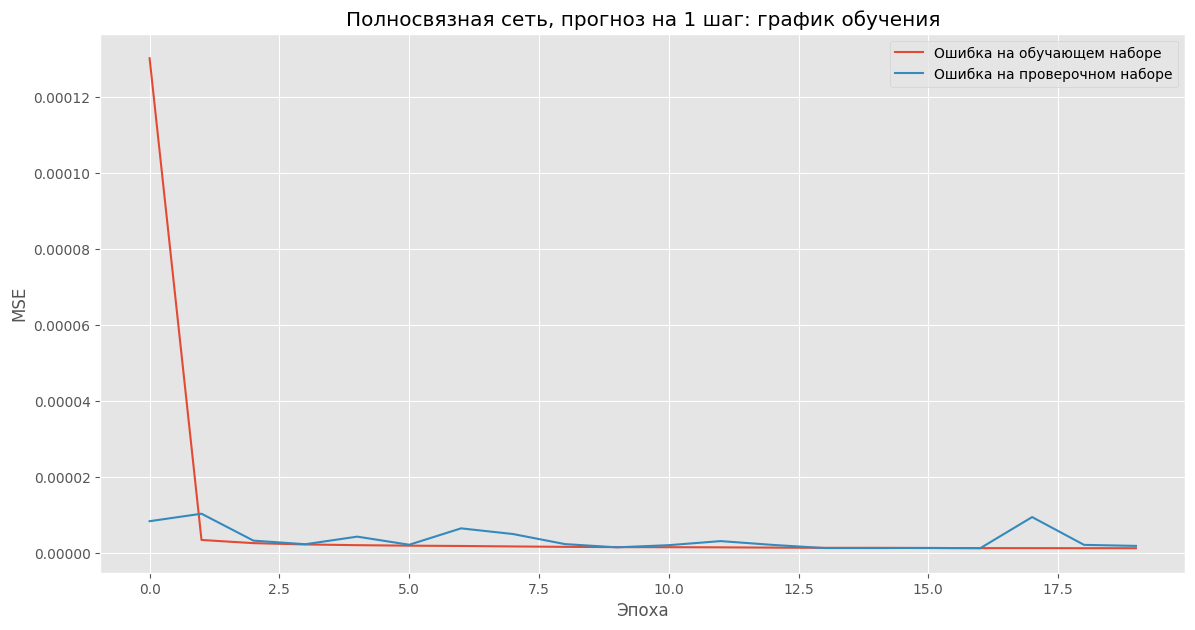

In [ ]:
# График ошибки обучения
plot_history(history_d1, 'Полносвязная сеть, прогноз на 1 шаг: график обучения')

### Визуализация результата

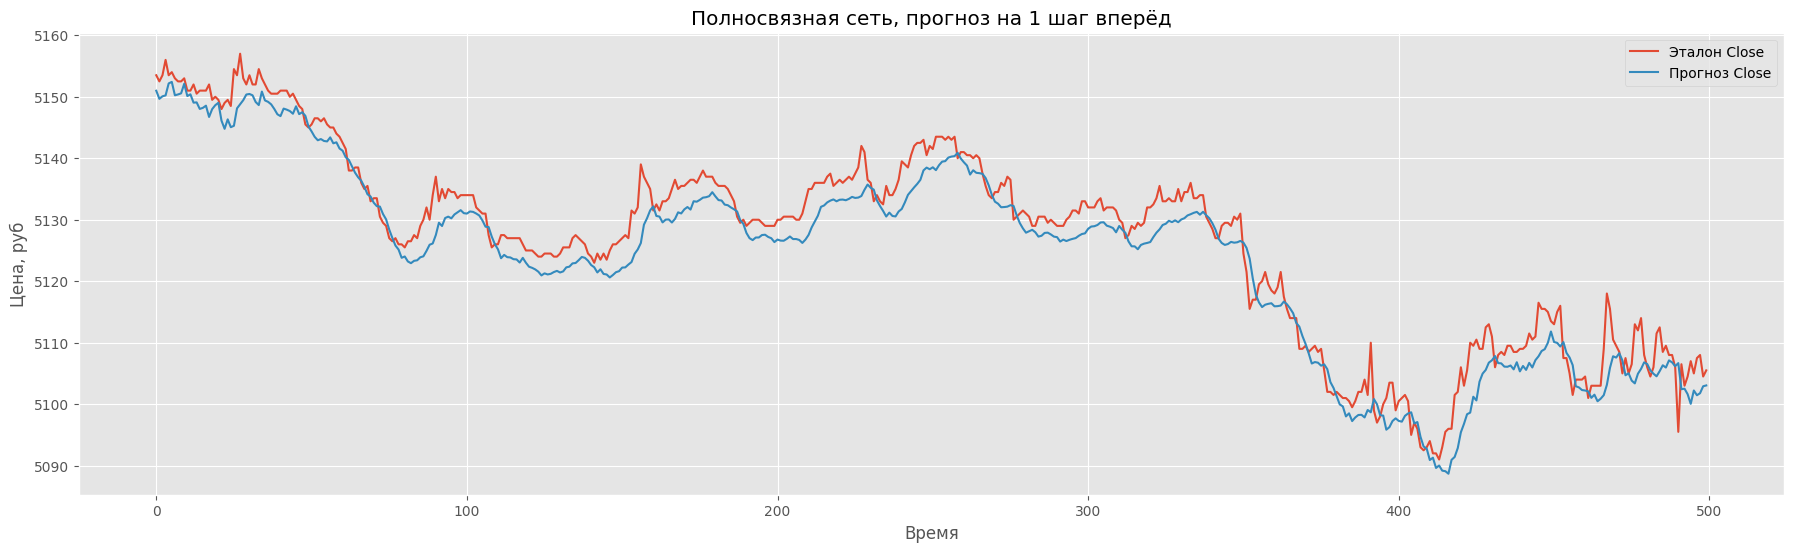

In [ ]:
# Предсказание на тестовой выборке и обратная нормализация
y_pred_d1_sc, y_true_d1_sc = predict_all(model_dense_1, test_ds_1)
y_pred_d1 = scaler.inverse_transform(y_pred_d1_sc)
y_true_d1 = scaler.inverse_transform(y_true_d1_sc)

# Сопоставление прогноза и эталона на участке длиной 500 точек
start = 0
length = 500

plt.figure(figsize=(22, 6))
plt.plot(y_true_d1[start:start + length], label='Эталон Close')
plt.plot(y_pred_d1[start:start + length], label='Прогноз Close')
plt.title('Полносвязная сеть, прогноз на 1 шаг вперёд')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.show()

## Часть 2. Полносвязная сеть, прямой прогноз на 10 шагов

При прямом способе прогноза на горизонт из нескольких шагов сеть выдаёт сразу вектор из соответствующего числа значений. То есть последний слой имеет 10 нейронов, и каждый нейрон отвечает за свою позицию в горизонте прогноза.

In [ ]:
# Та же архитектура, но с 10 выходами
class DenseModel10(nn.Module):
    def __init__(self, seq_len, predict_lag):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(seq_len, 150),
            nn.ReLU(),
            nn.Linear(150, predict_lag),
        )

    def forward(self, x):
        return self.net(x)


model_dense_10 = DenseModel10(SEQ_LEN, PREDICT_LAG).to(device)
print(model_dense_10)

DenseModel10(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=60, out_features=150, bias=True)
    (2): ReLU()
    (3): Linear(in_features=150, out_features=10, bias=True)
  )
)


In [ ]:
# Обучение
history_d10 = fit(model_dense_10, train_loader_10, test_loader_10, epochs=20, lr=1e-4)

Эпоха   1/20   loss = 0.001574   val_loss = 0.000009
Эпоха   2/20   loss = 0.000005   val_loss = 0.000006
Эпоха   3/20   loss = 0.000004   val_loss = 0.000006
Эпоха   4/20   loss = 0.000004   val_loss = 0.000005
Эпоха   5/20   loss = 0.000004   val_loss = 0.000005
Эпоха   6/20   loss = 0.000003   val_loss = 0.000005
Эпоха   7/20   loss = 0.000003   val_loss = 0.000004
Эпоха   8/20   loss = 0.000003   val_loss = 0.000004
Эпоха   9/20   loss = 0.000003   val_loss = 0.000014
Эпоха  10/20   loss = 0.000003   val_loss = 0.000004
Эпоха  11/20   loss = 0.000003   val_loss = 0.000004
Эпоха  12/20   loss = 0.000003   val_loss = 0.000005
Эпоха  13/20   loss = 0.000003   val_loss = 0.000006
Эпоха  14/20   loss = 0.000003   val_loss = 0.000004
Эпоха  15/20   loss = 0.000003   val_loss = 0.000008
Эпоха  16/20   loss = 0.000003   val_loss = 0.000006
Эпоха  17/20   loss = 0.000003   val_loss = 0.000005
Эпоха  18/20   loss = 0.000003   val_loss = 0.000005
Эпоха  19/20   loss = 0.000003   val_loss = 0.

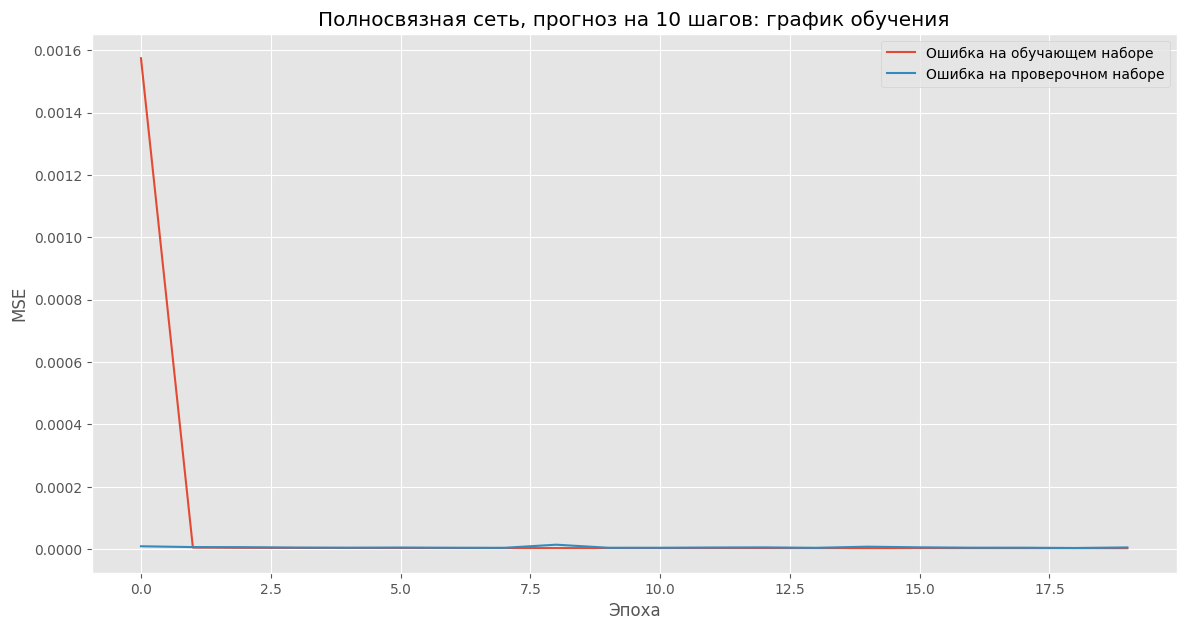

In [ ]:
# График ошибки обучения
plot_history(history_d10, 'Полносвязная сеть, прогноз на 10 шагов: график обучения')

### Графики сравнения предсказания и оригинального сигнала по 10 шагам

Каждый из 10 графиков соответствует одной позиции в горизонте прогноза: первый график — прогноз на 1 шаг вперёд, второй — на 2 шага вперёд, и так до 10. Эталонный ряд для каждого графика — фактические значения именно той позиции, на которую сеть делает прогноз.

In [ ]:
# Получение прогноза и его обратная нормализация
y_pred_m_sc, y_true_m_sc = predict_all(model_dense_10, test_ds_10)

# Канал был один, поэтому inverse_transform применяется к развёрнутому массиву и затем возвращается форма
y_pred_m = scaler.inverse_transform(y_pred_m_sc.reshape(-1, 1)).reshape(y_pred_m_sc.shape)
y_true_m = scaler.inverse_transform(y_true_m_sc.reshape(-1, 1)).reshape(y_true_m_sc.shape)

print('Денормализованный прогноз:', y_pred_m.shape)
print('Денормализованный эталон :', y_true_m.shape)

Денормализованный прогноз: (29811, 10)
Денормализованный эталон : (29811, 10)


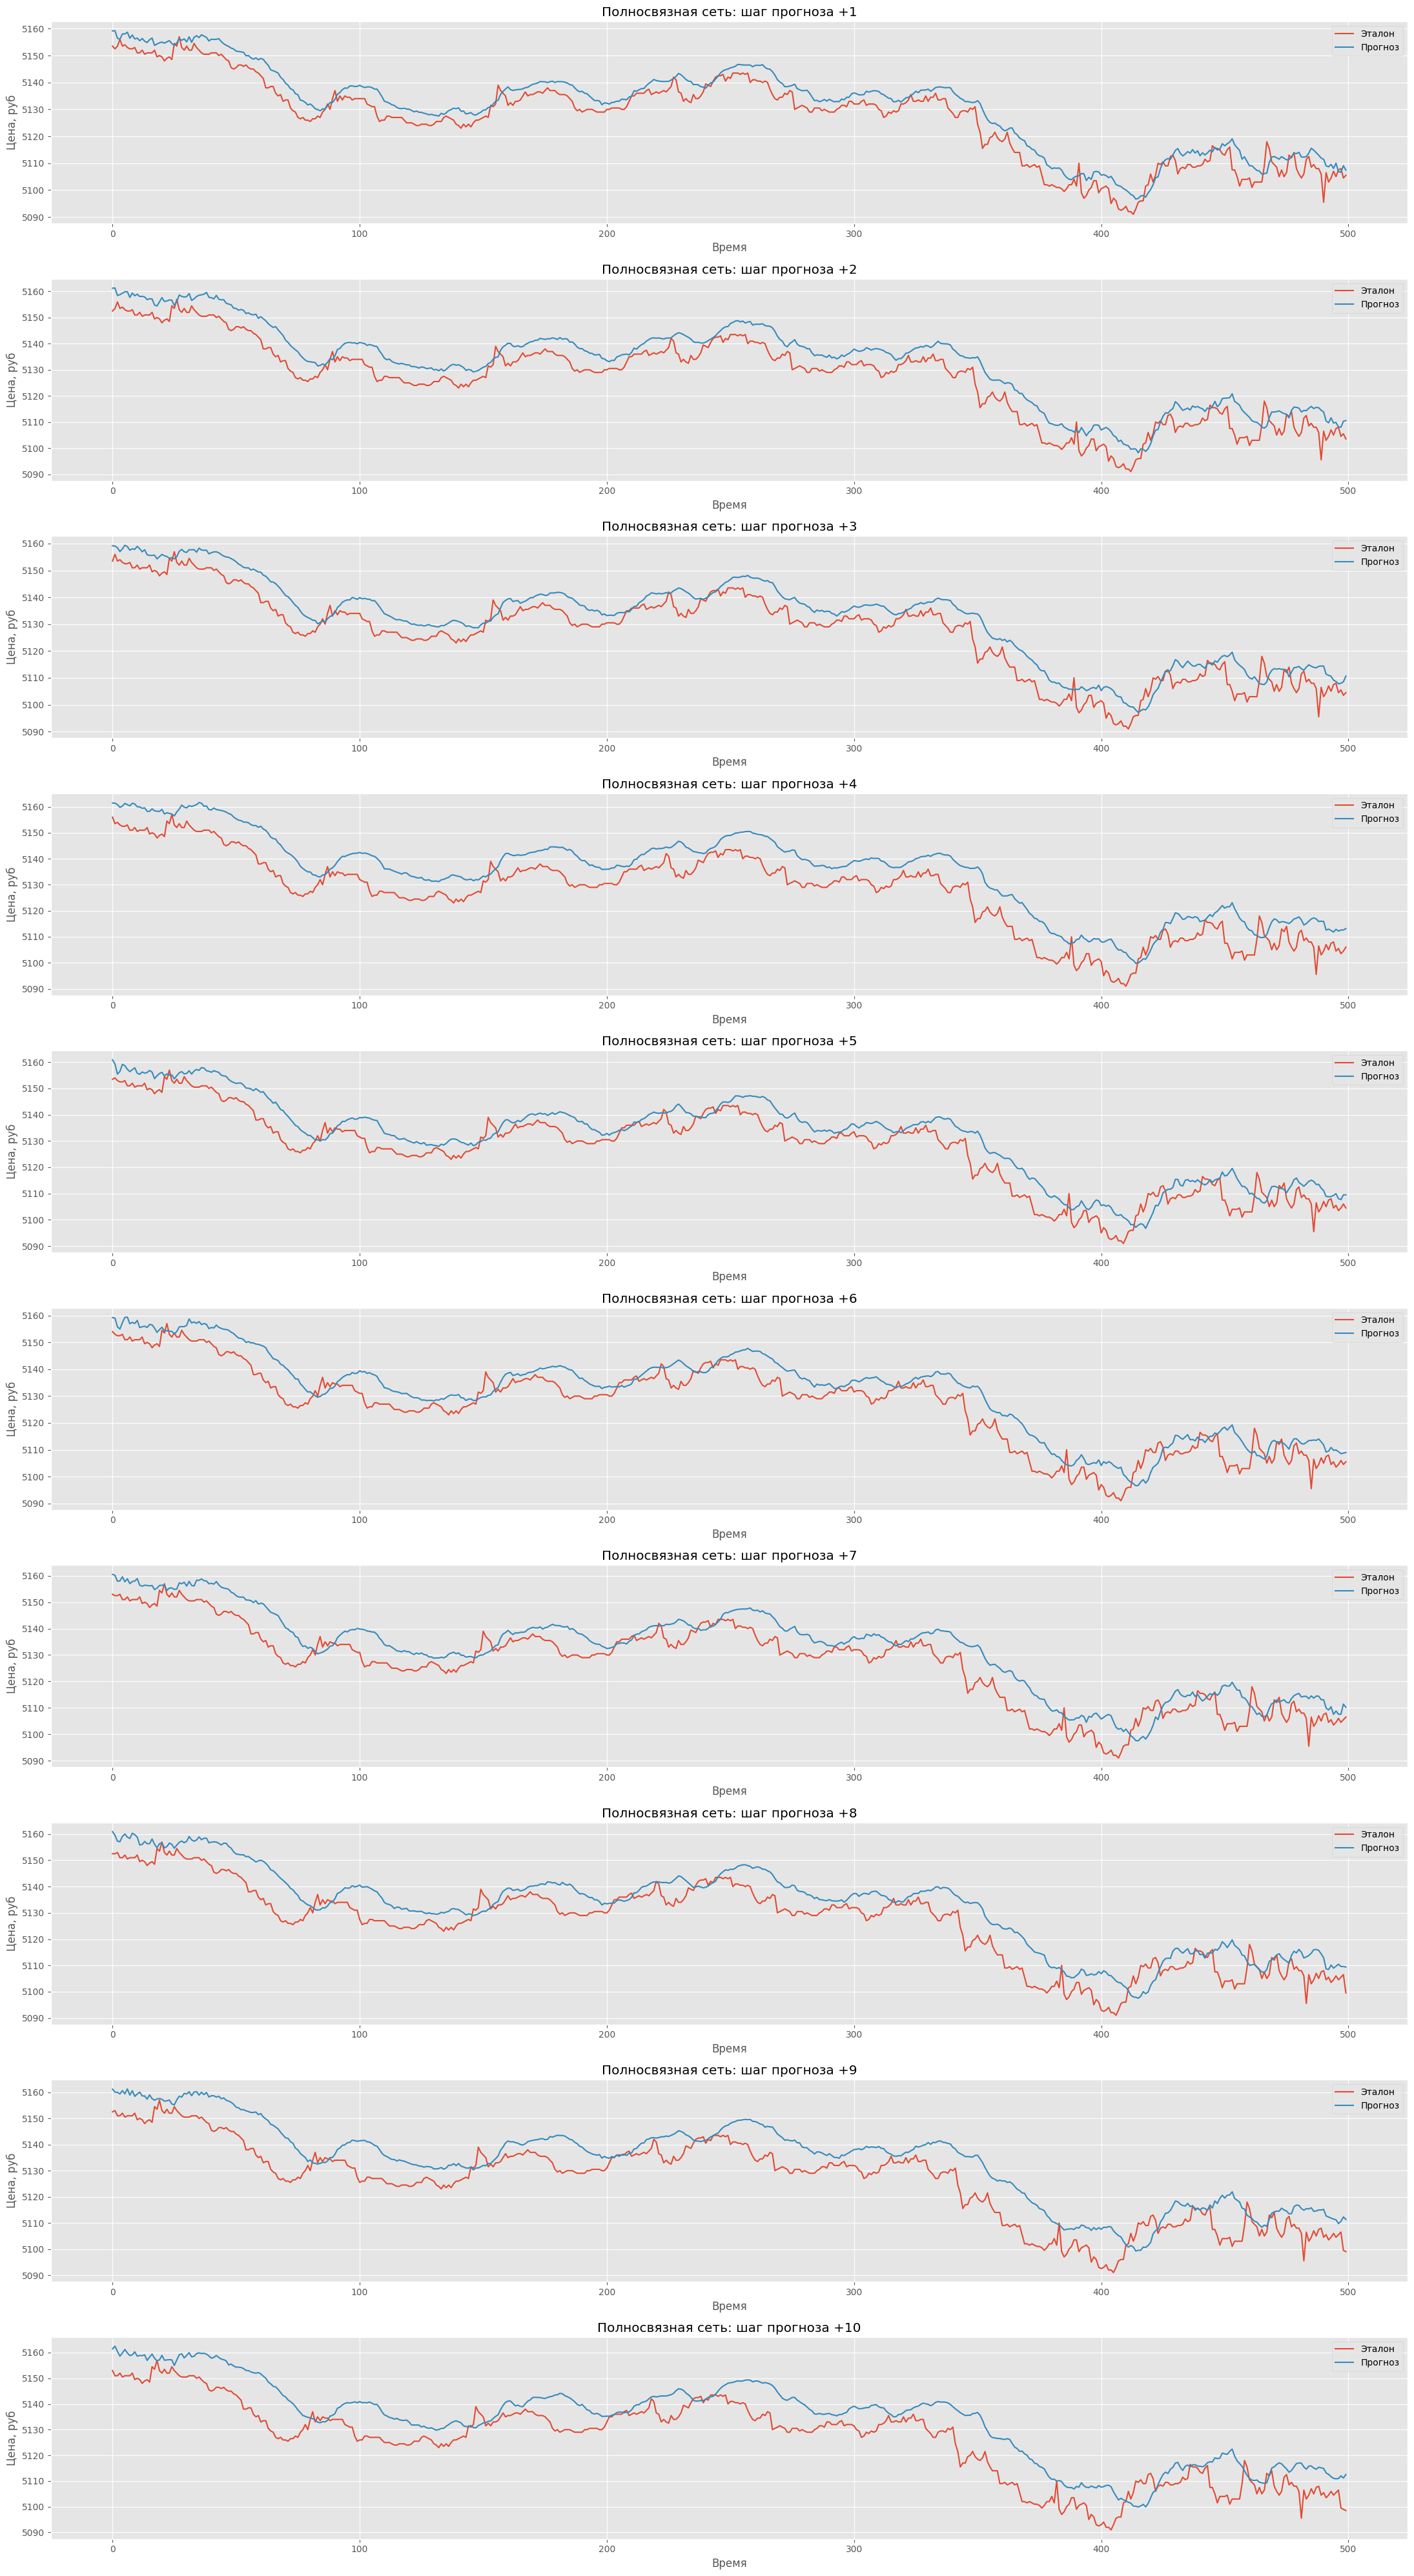

In [ ]:
# 10 отдельных графиков (10 рядов на разных осях)
start = 0
length = 500

fig, axes = plt.subplots(PREDICT_LAG, 1, figsize=(22, 4 * PREDICT_LAG))

for step in range(PREDICT_LAG):
    ax = axes[step]
    ax.plot(y_true_m[start:start + length, step], label='Эталон')
    ax.plot(y_pred_m[start:start + length, step], label='Прогноз')
    ax.set_title(f'Полносвязная сеть: шаг прогноза +{step + 1}')
    ax.set_xlabel('Время')
    ax.set_ylabel('Цена, руб')
    ax.legend()

plt.tight_layout()
plt.show()

На ближайших шагах прогноза предсказание полносвязной сети плотно повторяет эталон, что характерно для задач прогнозирования временных рядов с заметной автокорреляцией. По мере увеличения горизонта прогноза (шаги 5–10) предсказание начинает запаздывать и сглаживается, что закономерно: чем дальше прогноз, тем меньше информации о цели содержится во входном окне.

## Часть 3. Свёрточная сеть Conv1D

Для второй архитектуры используются одномерные свёрточные слои. Conv1D эффективен при работе с временными рядами: ядро свёртки обнаруживает локальные паттерны на коротких участках входной последовательности. В PyTorch слой `nn.Conv1d` ожидает тензор формы `(batch, channels, length)`, тогда как окно сформировано как `(batch, length, channels)`. Поэтому в начале модели выполняется перестановка осей.

### Conv1D, прогноз на 1 шаг

In [ ]:
# Сеть Conv1D с одним выходом
class ConvModel1(nn.Module):
    def __init__(self, seq_len):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5),
            nn.ReLU(),
        )
        # После двух Conv1D без padding длина уменьшается на (kernel - 1) дважды: seq_len - 8
        conv_out_len = seq_len - 8
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * conv_out_len, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
        )

    def forward(self, x):
        # x: (batch, seq_len, 1) -> (batch, 1, seq_len)
        x = x.transpose(1, 2)
        x = self.conv(x)
        return self.head(x)


model_conv_1 = ConvModel1(SEQ_LEN).to(device)
print(model_conv_1)

ConvModel1(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
    (3): ReLU()
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3328, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=1, bias=True)
  )
)


In [ ]:
# Обучение
history_c1 = fit(model_conv_1, train_loader_1, test_loader_1, epochs=15, lr=1e-4)

Эпоха   1/15   loss = 0.000154   val_loss = 0.000012
Эпоха   2/15   loss = 0.000008   val_loss = 0.000005
Эпоха   3/15   loss = 0.000006   val_loss = 0.000033
Эпоха   4/15   loss = 0.000005   val_loss = 0.000007
Эпоха   5/15   loss = 0.000004   val_loss = 0.000012
Эпоха   6/15   loss = 0.000003   val_loss = 0.000005
Эпоха   7/15   loss = 0.000003   val_loss = 0.000002
Эпоха   8/15   loss = 0.000002   val_loss = 0.000001
Эпоха   9/15   loss = 0.000002   val_loss = 0.000002
Эпоха  10/15   loss = 0.000002   val_loss = 0.000003
Эпоха  11/15   loss = 0.000002   val_loss = 0.000001
Эпоха  12/15   loss = 0.000002   val_loss = 0.000005
Эпоха  13/15   loss = 0.000002   val_loss = 0.000001
Эпоха  14/15   loss = 0.000001   val_loss = 0.000001
Эпоха  15/15   loss = 0.000001   val_loss = 0.000001


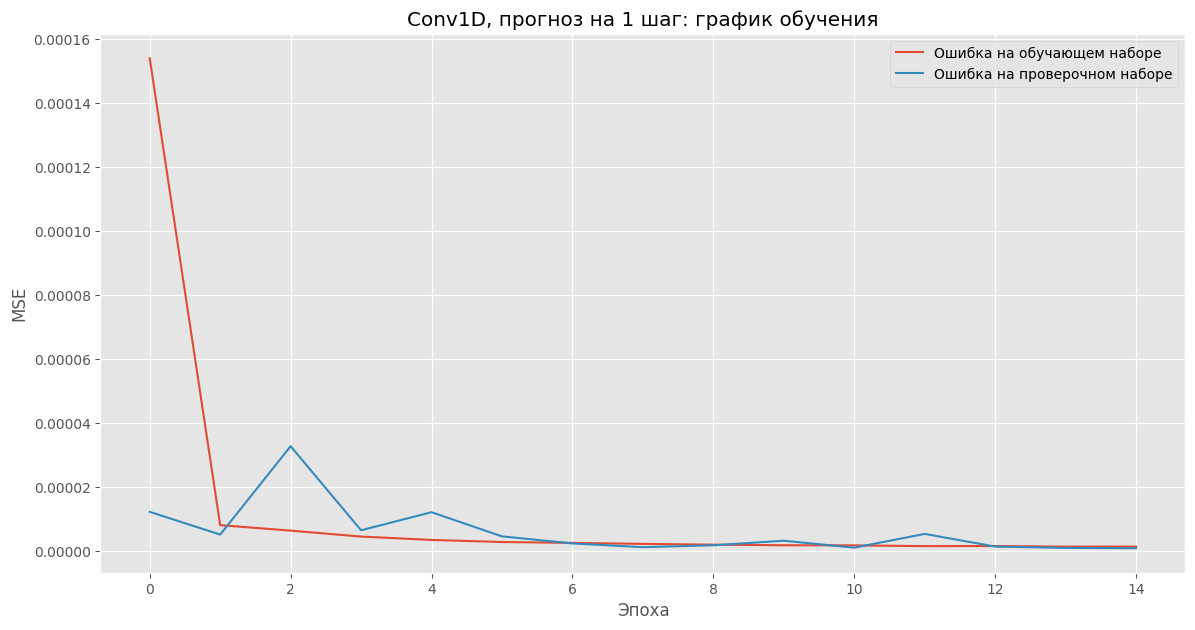

In [ ]:
# График обучения
plot_history(history_c1, 'Conv1D, прогноз на 1 шаг: график обучения')

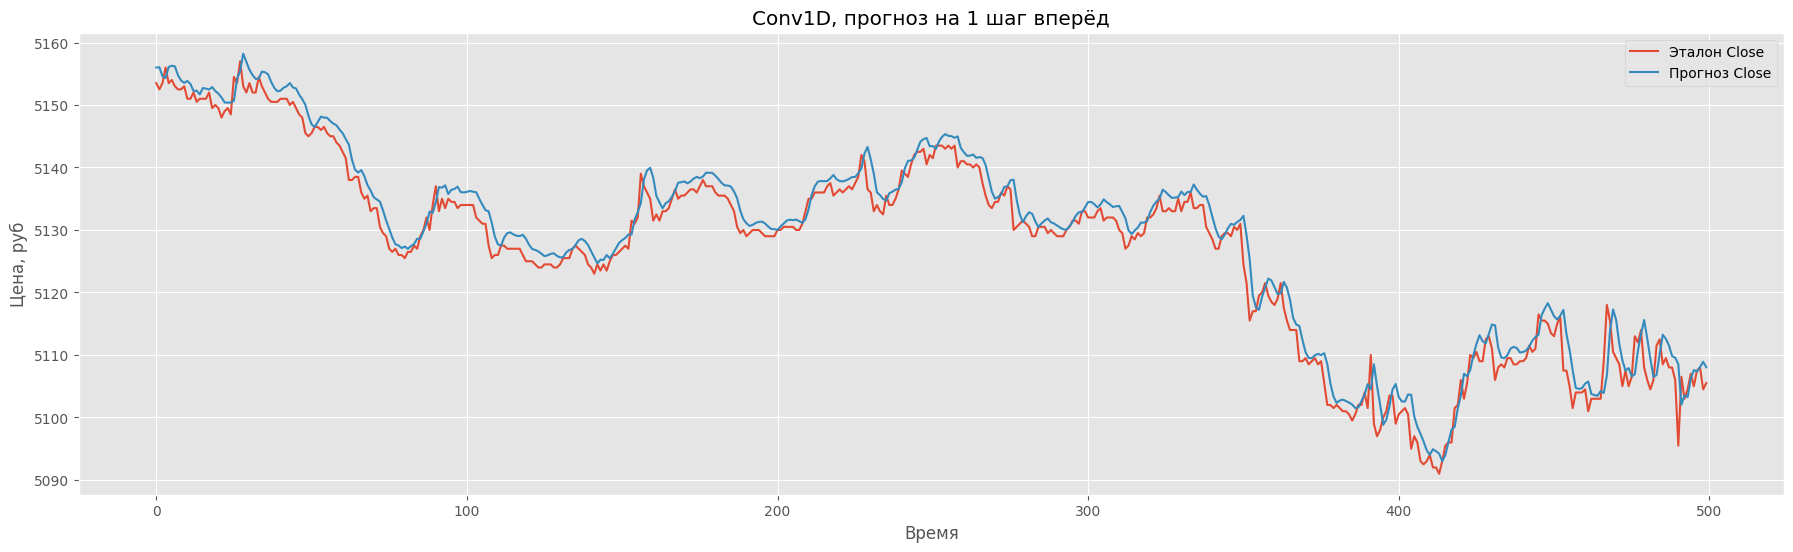

In [ ]:
# Сопоставление прогноза и эталона
y_pred_c1_sc, y_true_c1_sc = predict_all(model_conv_1, test_ds_1)
y_pred_c1 = scaler.inverse_transform(y_pred_c1_sc)
y_true_c1 = scaler.inverse_transform(y_true_c1_sc)

start = 0
length = 500

plt.figure(figsize=(22, 6))
plt.plot(y_true_c1[start:start + length], label='Эталон Close')
plt.plot(y_pred_c1[start:start + length], label='Прогноз Close')
plt.title('Conv1D, прогноз на 1 шаг вперёд')
plt.xlabel('Время')
plt.ylabel('Цена, руб')
plt.legend()
plt.show()

### Conv1D, прямой прогноз на 10 шагов

In [ ]:
# Conv1D с 10 выходами
class ConvModel10(nn.Module):
    def __init__(self, seq_len, predict_lag):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=5),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=5),
            nn.ReLU(),
        )
        conv_out_len = seq_len - 8
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * conv_out_len, 100),
            nn.ReLU(),
            nn.Linear(100, predict_lag),
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.conv(x)
        return self.head(x)


model_conv_10 = ConvModel10(SEQ_LEN, PREDICT_LAG).to(device)
print(model_conv_10)

ConvModel10(
  (conv): Sequential(
    (0): Conv1d(1, 64, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
    (3): ReLU()
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3328, out_features=100, bias=True)
    (2): ReLU()
    (3): Linear(in_features=100, out_features=10, bias=True)
  )
)


In [ ]:
# Обучение
history_c10 = fit(model_conv_10, train_loader_10, test_loader_10, epochs=15, lr=1e-4)

Эпоха   1/15   loss = 0.000420   val_loss = 0.000063
Эпоха   2/15   loss = 0.000009   val_loss = 0.000010
Эпоха   3/15   loss = 0.000007   val_loss = 0.000011
Эпоха   4/15   loss = 0.000006   val_loss = 0.000008
Эпоха   5/15   loss = 0.000005   val_loss = 0.000007
Эпоха   6/15   loss = 0.000005   val_loss = 0.000006
Эпоха   7/15   loss = 0.000004   val_loss = 0.000006
Эпоха   8/15   loss = 0.000004   val_loss = 0.000004
Эпоха   9/15   loss = 0.000004   val_loss = 0.000005
Эпоха  10/15   loss = 0.000004   val_loss = 0.000005
Эпоха  11/15   loss = 0.000004   val_loss = 0.000004
Эпоха  12/15   loss = 0.000003   val_loss = 0.000005
Эпоха  13/15   loss = 0.000003   val_loss = 0.000006
Эпоха  14/15   loss = 0.000003   val_loss = 0.000005
Эпоха  15/15   loss = 0.000003   val_loss = 0.000004


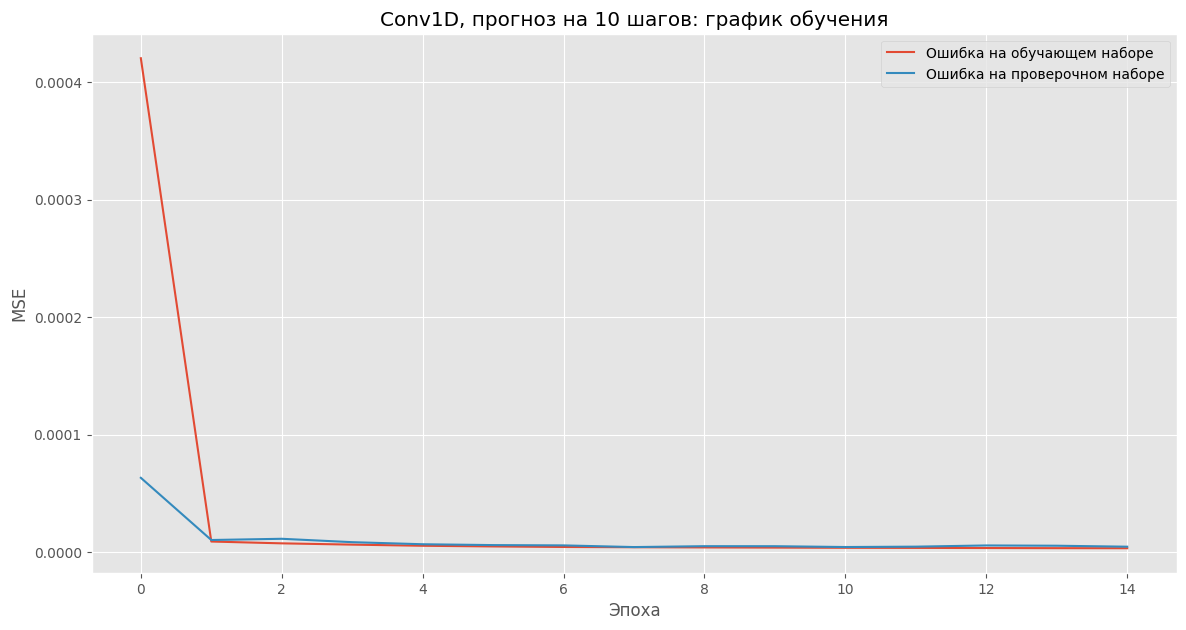

In [ ]:
# График обучения
plot_history(history_c10, 'Conv1D, прогноз на 10 шагов: график обучения')

### Графики сравнения предсказания Conv1D с оригинальным сигналом по 10 шагам

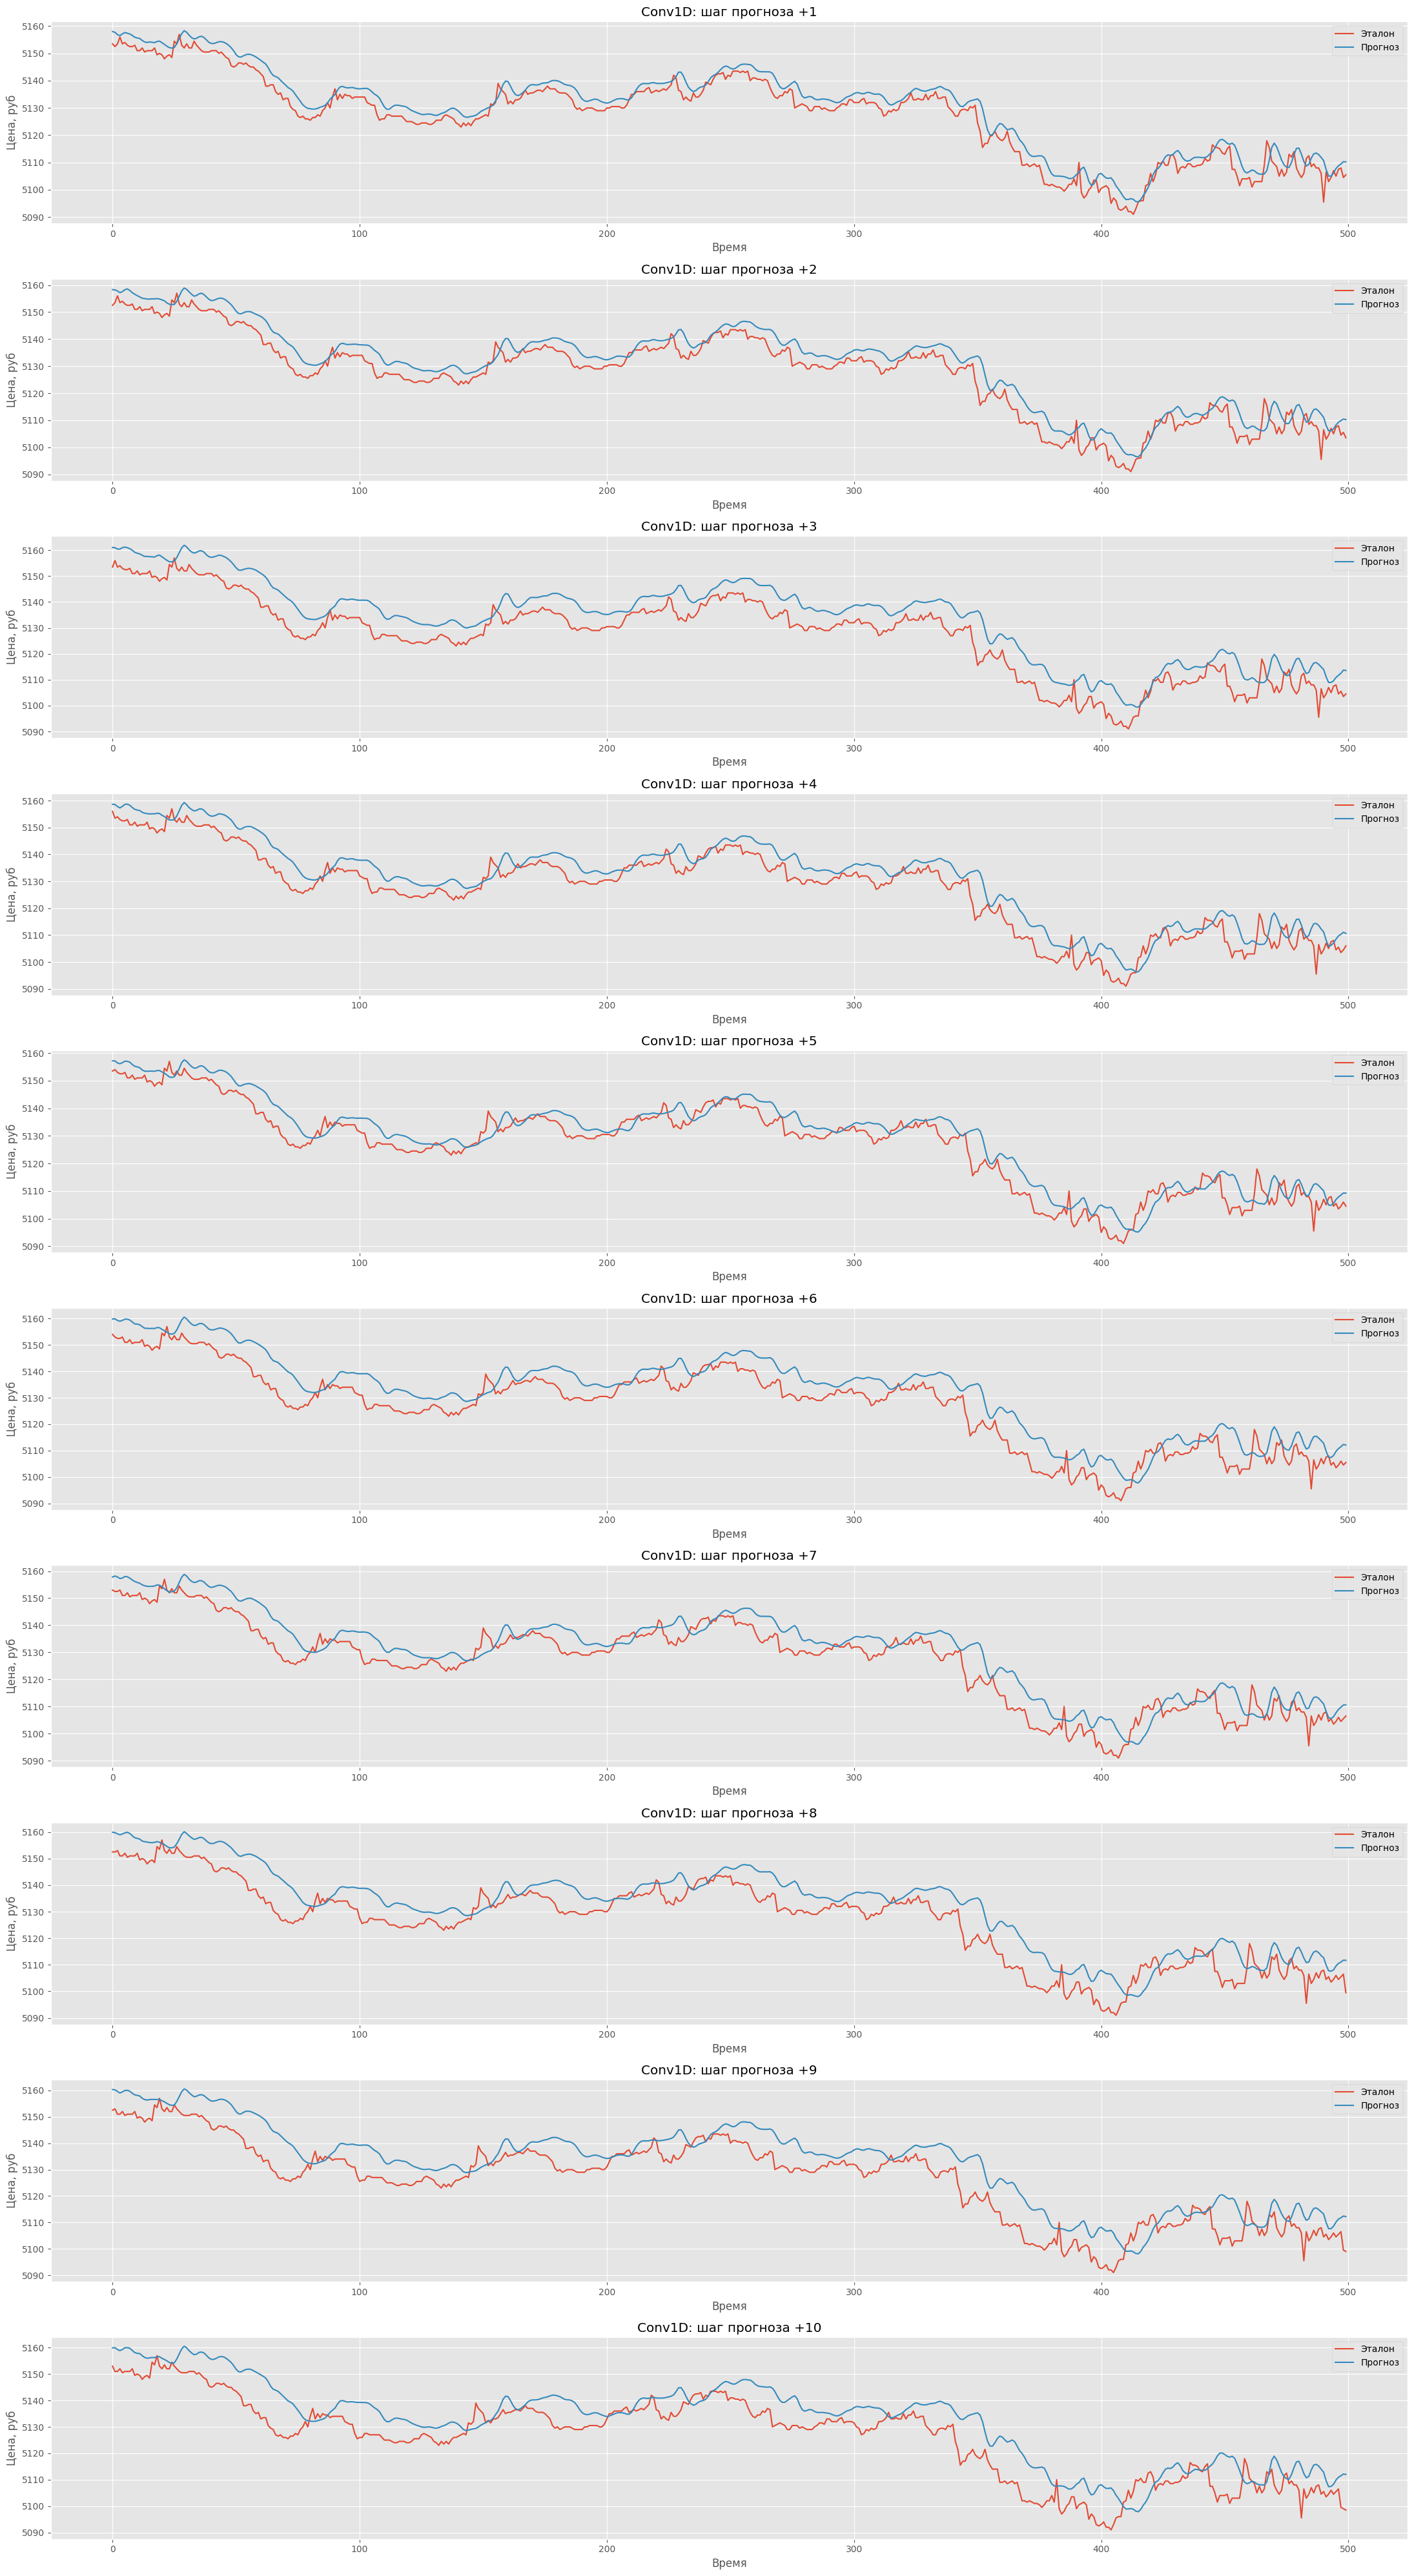

In [ ]:
# Прогноз на тестовой выборке и обратная нормализация
y_pred_cm_sc, y_true_cm_sc = predict_all(model_conv_10, test_ds_10)
y_pred_cm = scaler.inverse_transform(y_pred_cm_sc.reshape(-1, 1)).reshape(y_pred_cm_sc.shape)
y_true_cm = scaler.inverse_transform(y_true_cm_sc.reshape(-1, 1)).reshape(y_true_cm_sc.shape)

# 10 отдельных графиков
start = 0
length = 500

fig, axes = plt.subplots(PREDICT_LAG, 1, figsize=(22, 4 * PREDICT_LAG))

for step in range(PREDICT_LAG):
    ax = axes[step]
    ax.plot(y_true_cm[start:start + length, step], label='Эталон')
    ax.plot(y_pred_cm[start:start + length, step], label='Прогноз')
    ax.set_title(f'Conv1D: шаг прогноза +{step + 1}')
    ax.set_xlabel('Время')
    ax.set_ylabel('Цена, руб')
    ax.legend()

plt.tight_layout()
plt.show()